# Аналитический отчет по данным о рейсах из Нью-Йорка

В работе исследуются данные о рейсах и самолетах. По каждому вопросу отчет оформлен в единой структуре: что исследуем, каким методом отвечаем на вопрос, какие результаты получаем и какой вывод делаем.

## Данные и подготовка

Используется файл `flights_NY.csv`. Перед анализом удаляем строки с пропусками и рассчитываем дополнительный показатель `speed` как среднюю скорость рейса в милях в час.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, ttest_ind
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

data_path = Path('data/flights_NY.csv')
df = pd.read_csv(data_path).dropna().copy()
df['speed'] = df['distance'] / (df['air_time'] / 60)

print(f'Строк после очистки: {len(df)}')
print(f'Средняя скорость: {df["speed"].mean():.1f} mph')
display(df.head())

Строк после очистки: 327346
Средняя скорость: 394.3 mph


,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,speed
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,370.044053
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,374.273128
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,408.375000
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,516.721311
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762,394.137931


## Задание 1

### Что исследуем
Определяем, у какой авиакомпании с парком более 200 самолетов выше вероятность задержки вылета.

### Метод
Для каждой авиакомпании считаем число уникальных самолетов, число рейсов и долю рейсов с `dep_delay > 0`. В анализ включаем только компании, у которых более 200 самолетов. Результат показываем в таблице и на столбчатой диаграмме.

,carrier,n_planes,n_flights,p_delay
2,DL,626,47658,0.318645
5,UA,620,57782,0.469437
1,AA,600,31947,0.316305
7,WN,581,12044,0.542594
3,EV,316,51108,0.449558
6,US,289,19831,0.240129
4,MQ,237,25037,0.318169
0,9E,203,17294,0.403608


Максимальная вероятность задержки у WN: 0.543


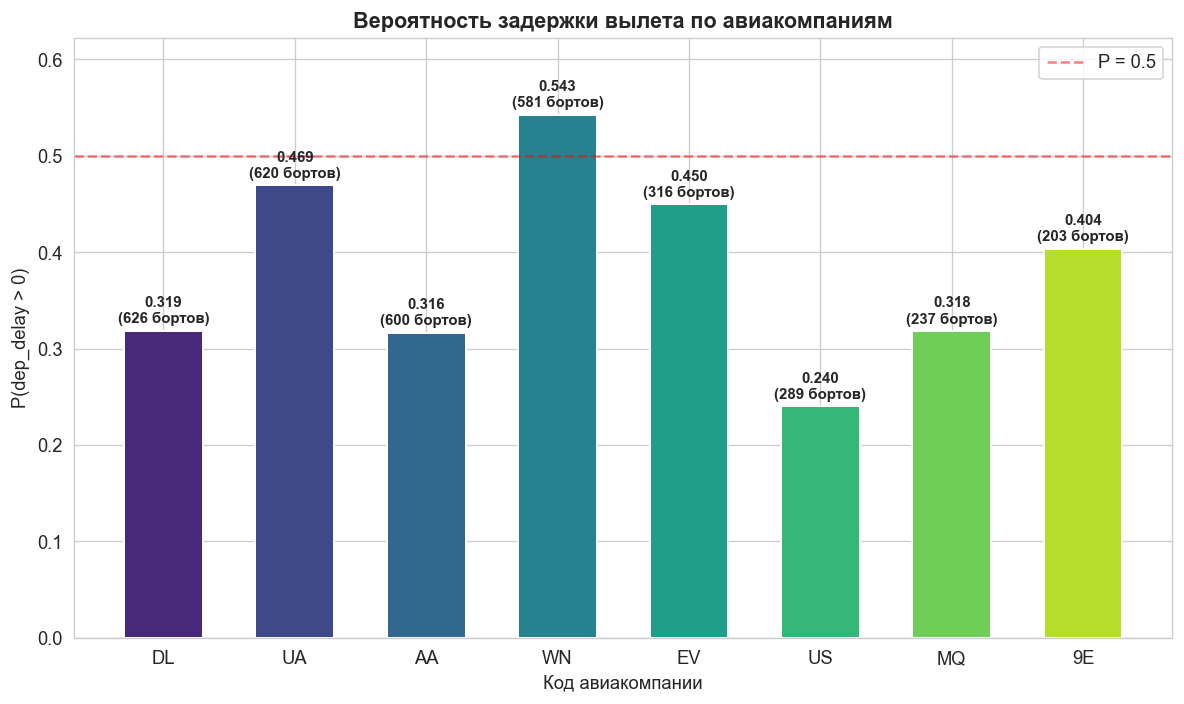

In [2]:
fleet_size = df.groupby('carrier')['tailnum'].nunique()
large_carriers = fleet_size[fleet_size > 200].index
df_large = df[df['carrier'].isin(large_carriers)].copy()

delay_prob = df_large.groupby('carrier').agg(
    n_planes=('tailnum', 'nunique'),
    n_flights=('flight', 'count'),
    p_delay=('dep_delay', lambda x: (x > 0).mean())
).reset_index().sort_values('n_planes', ascending=False)

display(delay_prob)
top_carrier = delay_prob.loc[delay_prob['p_delay'].idxmax(), 'carrier']
top_prob = delay_prob['p_delay'].max()
print(f'Максимальная вероятность задержки у {top_carrier}: {top_prob:.3f}')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    delay_prob['carrier'],
    delay_prob['p_delay'],
    color=sns.color_palette('viridis', len(delay_prob)),
    edgecolor='white', linewidth=1.2, width=0.6
)
for bar, (_, row) in zip(bars, delay_prob.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{row['p_delay']:.3f}\n({row['n_planes']} бортов)",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
ax.set_title('Вероятность задержки вылета по авиакомпаниям', fontsize=13, fontweight='bold')
ax.set_xlabel('Код авиакомпании')
ax.set_ylabel('P(dep_delay > 0)')
ax.set_ylim(0, delay_prob['p_delay'].max() + 0.08)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='P = 0.5')
ax.legend()
plt.tight_layout()
plt.savefig('charts/1_delay_by_carrier.png', bbox_inches='tight')
plt.show()

### Вывод
Среди авиакомпаний с парком более 200 самолетов наибольшая вероятность задержки вылета наблюдается у `WN`. По расчетам доля рейсов с задержкой составляет примерно `0.543`, то есть более половины вылетов происходят с положительной задержкой.

## Задание 2

### Что исследуем
Оцениваем распределение среднего времени в воздухе по самолетам и строим 95%-й диапазон вокруг среднего значения.

### Метод
Для каждого самолета считаем среднее `air_time`, затем по полученному распределению оцениваем среднее значение `μ`, стандартное отклонение `σ` и 95%-й диапазон по формуле `μ ± 1.96σ`. Для интерпретации строим гистограмму и накладываем нормальную кривую.

μ = 157.50 минут
σ = 75.80 минут
95% диапазон: [8.9, 306.1] минут


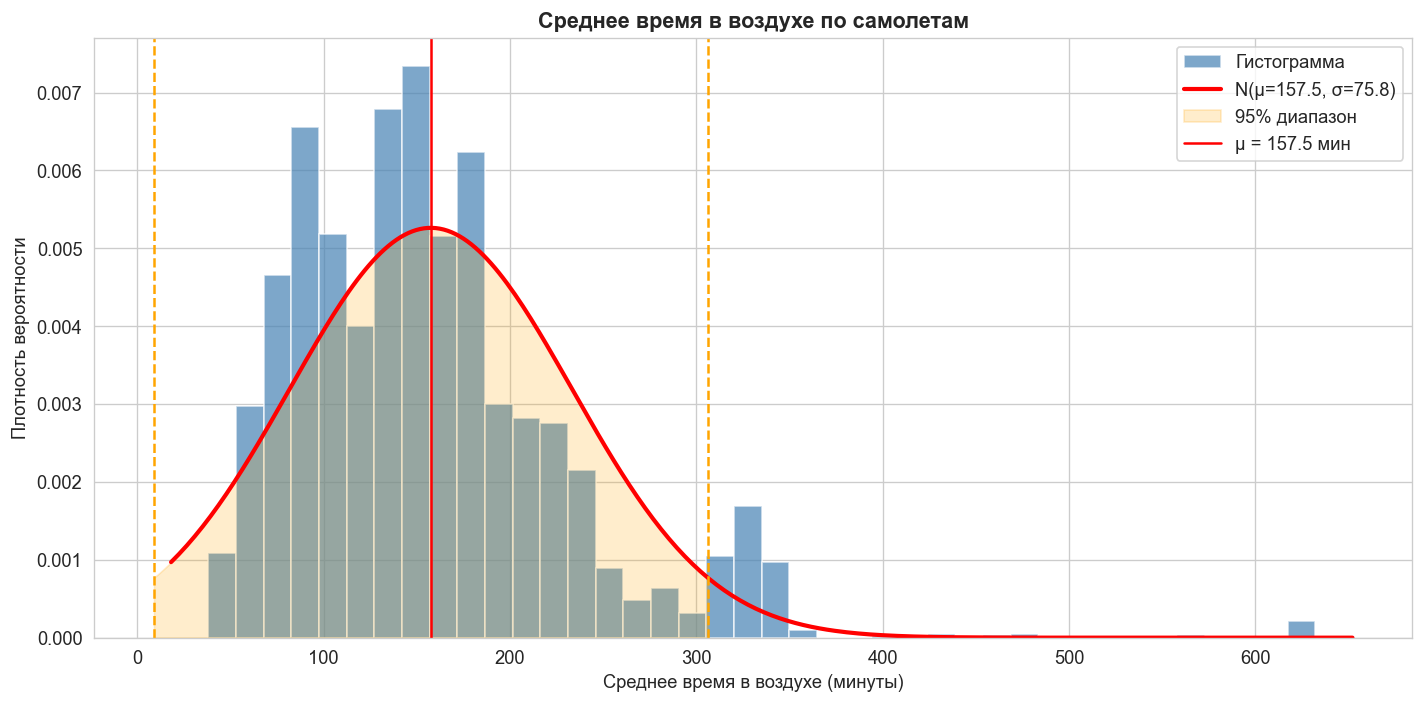

In [3]:
plane_airtime = df.groupby('tailnum')['air_time'].mean()
mu = plane_airtime.mean()
sigma = plane_airtime.std()
z_95 = norm.ppf(0.975)
lower_95 = mu - z_95 * sigma
upper_95 = mu + z_95 * sigma

print(f'μ = {mu:.2f} минут')
print(f'σ = {sigma:.2f} минут')
print(f'95% диапазон: [{lower_95:.1f}, {upper_95:.1f}] минут')

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(plane_airtime, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white', label='Гистограмма')
x_range = np.linspace(plane_airtime.min() - 20, plane_airtime.max() + 20, 300)
ax.plot(x_range, norm.pdf(x_range, mu, sigma), 'r-', linewidth=2.5, label=f'N(μ={mu:.1f}, σ={sigma:.1f})')
x_fill = np.linspace(lower_95, upper_95, 300)
ax.fill_between(x_fill, norm.pdf(x_fill, mu, sigma), alpha=0.2, color='orange', label='95% диапазон')
ax.axvline(lower_95, color='orange', linestyle='--', linewidth=1.5)
ax.axvline(upper_95, color='orange', linestyle='--', linewidth=1.5)
ax.axvline(mu, color='red', linestyle='-', linewidth=1.5, label=f'μ = {mu:.1f} мин')
ax.set_title('Среднее время в воздухе по самолетам', fontsize=13, fontweight='bold')
ax.set_xlabel('Среднее время в воздухе (минуты)')
ax.set_ylabel('Плотность вероятности')
ax.legend()
plt.tight_layout()
plt.savefig('charts/2_airtime_distribution.png', bbox_inches='tight')
plt.show()

### Вывод
Среднее время в воздухе по самолетам составляет около `157.5` минут, а стандартное отклонение равно `75.8` минут. 95%-й диапазон по нормальной аппроксимации равен примерно `[8.9; 306.1]` минут, что отражает заметную неоднородность самолетов по типичным маршрутам и длительности полета.

## Задание 3

### Что исследуем
Проверяем, различается ли средняя скорость самолетов авиакомпаний `WN` и `UA` статистически значимо.

### Метод
Для каждой из двух компаний считаем среднюю скорость по каждому самолету. Затем применяем двухвыборочный t-тест и дополнительно оцениваем 95%-е доверительные интервалы для средних значений. Для наглядности строим распределения и выделяем интервалы на графиках.

WN: 581 самолетов, средняя скорость = 397.6 mph
UA: 620 самолетов, средняя скорость = 423.4 mph
t-статистика = -27.0956
p-value = 0.000000


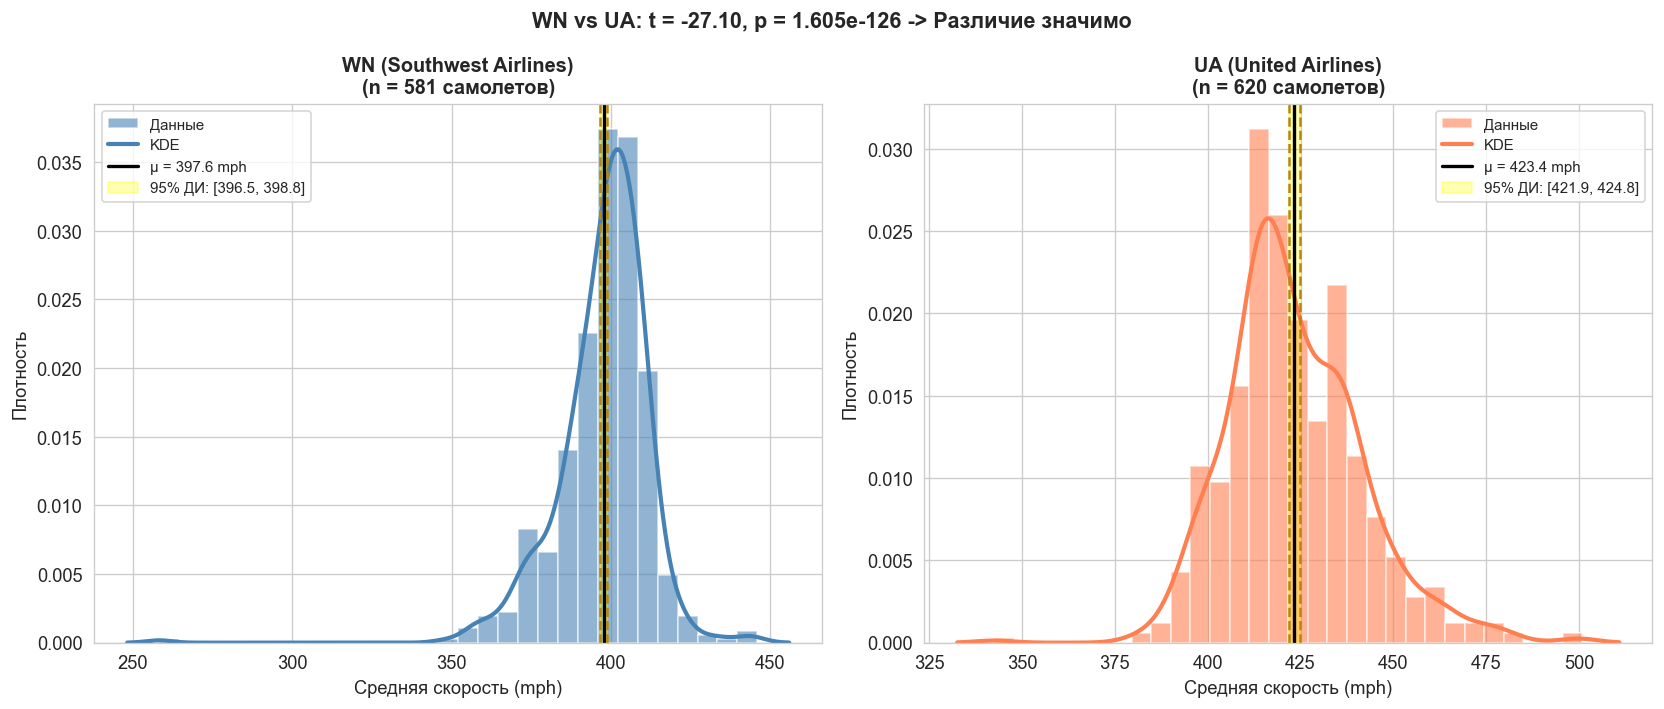

In [4]:
speed_wn = df[df['carrier'] == 'WN'].groupby('tailnum')['speed'].mean()
speed_ua = df[df['carrier'] == 'UA'].groupby('tailnum')['speed'].mean()

t_stat, p_value = ttest_ind(speed_wn, speed_ua)

def ci95(data):
    mean = np.mean(data)
    se = stats.sem(data)
    margin = stats.t.ppf(0.975, df=len(data) - 1) * se
    return mean, mean - margin, mean + margin

wn_ci = ci95(speed_wn)
ua_ci = ci95(speed_ua)

print(f'WN: {len(speed_wn)} самолетов, средняя скорость = {speed_wn.mean():.1f} mph')
print(f'UA: {len(speed_ua)} самолетов, средняя скорость = {speed_ua.mean():.1f} mph')
print(f't-статистика = {t_stat:.4f}')
print(f'p-value = {p_value:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, label, color, ci in zip(
    axes,
    [speed_wn, speed_ua],
    ['WN (Southwest Airlines)', 'UA (United Airlines)'],
    ['steelblue', 'coral'],
    [wn_ci, ua_ci]
):
    ax.hist(data, bins=30, density=True, alpha=0.6, color=color, edgecolor='white', label='Данные')
    x_range = np.linspace(data.min() - 10, data.max() + 10, 300)
    ax.plot(x_range, stats.gaussian_kde(data)(x_range), color=color, linewidth=2.5, label='KDE')
    ax.axvline(ci[0], color='black', linestyle='-', linewidth=2, label=f'μ = {ci[0]:.1f} mph')
    ax.axvspan(ci[1], ci[2], alpha=0.3, color='yellow', label=f'95% ДИ: [{ci[1]:.1f}, {ci[2]:.1f}]')
    ax.axvline(ci[1], color='darkgoldenrod', linestyle='--', linewidth=1.5)
    ax.axvline(ci[2], color='darkgoldenrod', linestyle='--', linewidth=1.5)
    ax.set_title(f'{label}\n(n = {len(data)} самолетов)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Средняя скорость (mph)')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=9)

decision = 'Различие значимо' if p_value < 0.05 else 'Различие незначимо'
fig.suptitle(f'WN vs UA: t = {t_stat:.2f}, p = {p_value:.4g} -> {decision}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/3_speed_wn_ua.png', bbox_inches='tight')
plt.show()

### Вывод
Средняя скорость самолетов `UA` выше, чем у `WN`: примерно `423.4 mph` против `397.6 mph`. Значение `p-value` практически равно нулю, поэтому нулевая гипотеза о равенстве средних отвергается. Различие между компаниями статистически значимо.

## Задание 4

### Что исследуем
Исследуем зависимость между средней скоростью самолета и средним расстоянием его рейсов.

### Метод
По каждому самолету рассчитываем среднюю скорость, среднюю дистанцию и число рейсов. Оставляем только самолеты минимум с 5 рейсами, чтобы убрать слишком шумные наблюдения. Затем строим полиномиальную регрессию второй степени и оцениваем качество модели по коэффициенту детерминации `R²`.

/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


R² = 0.8054


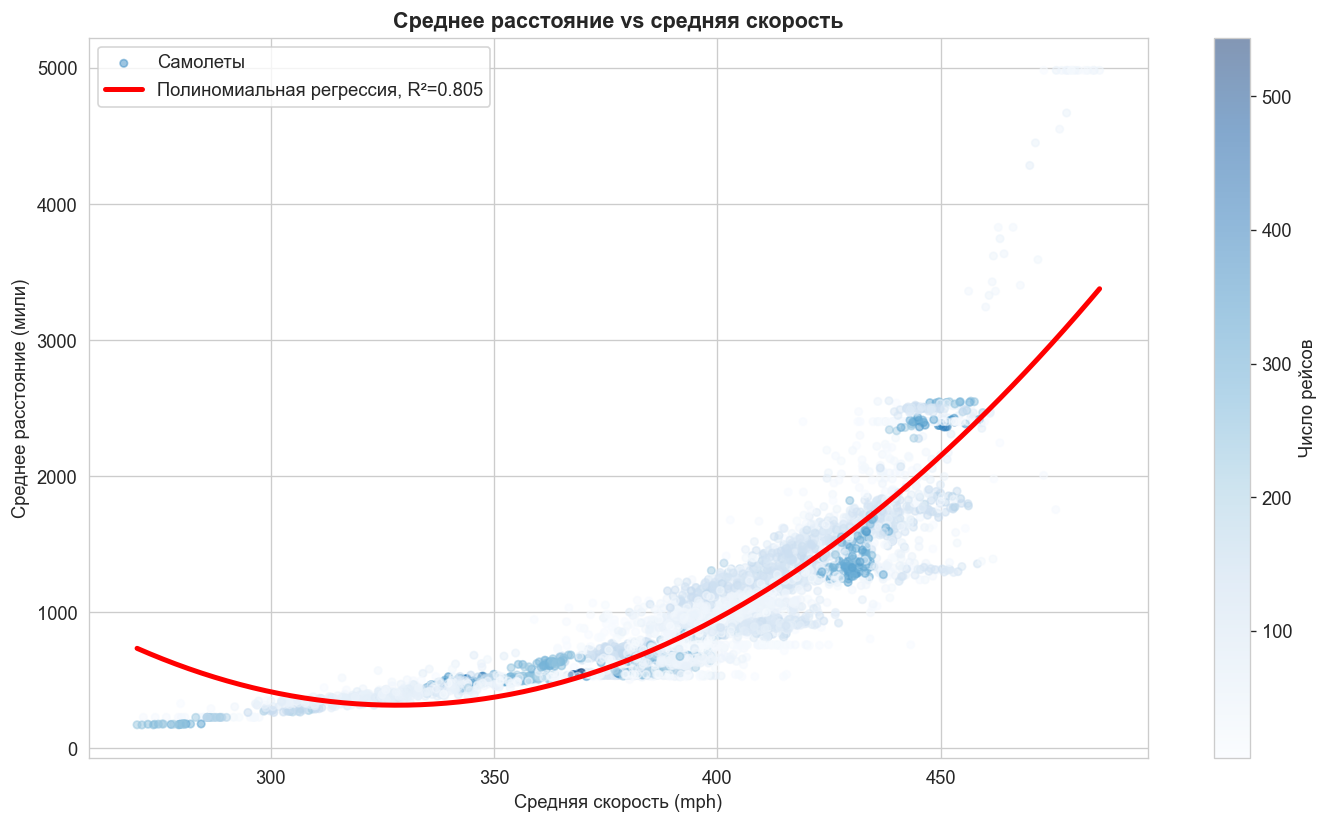

In [5]:
plane_stats = df.groupby('tailnum').agg(
    mean_speed=('speed', 'mean'),
    mean_distance=('distance', 'mean'),
    n_flights=('flight', 'count')
).reset_index()
plane_stats = plane_stats[plane_stats['n_flights'] >= 5].copy()

X = plane_stats['mean_speed'].to_numpy().reshape(-1, 1)
y = plane_stats['mean_distance'].to_numpy()

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)
r2 = model.score(X_poly, y)

print(f'R² = {r2:.4f}')

x_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_pred_line = model.predict(poly.transform(x_line))

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(plane_stats['mean_speed'], plane_stats['mean_distance'], c=plane_stats['n_flights'], cmap='Blues', alpha=0.5, s=20, label='Самолеты')
plt.colorbar(sc, ax=ax, label='Число рейсов')
ax.plot(x_line, y_pred_line, 'r-', linewidth=3, label=f'Полиномиальная регрессия, R²={r2:.3f}')
ax.set_title('Среднее расстояние vs средняя скорость', fontsize=13, fontweight='bold')
ax.set_xlabel('Средняя скорость (mph)')
ax.set_ylabel('Среднее расстояние (мили)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/4_speed_vs_distance.png', bbox_inches='tight')
plt.show()

### Вывод
Между средней скоростью самолета и средней дальностью его рейсов наблюдается сильная нелинейная связь. Модель второй степени дает `R² ≈ 0.805`, то есть объясняет около `80.5%` вариации среднего расстояния. Это означает, что более быстрые самолеты обычно обслуживают более дальние маршруты.

## Задание 5

### Что исследуем
Разбиваем самолеты на кластеры по средней скорости и числу рейсов, чтобы выявить типичные группы эксплуатационного поведения.

### Метод
Берем признаки `mean_speed` и `n_flights`, масштабируем их и применяем `K-Means`. Число кластеров выбираем как `k = 4`, ориентируясь на метод локтя и интерпретируемость результата. После кластеризации анализируем средние характеристики групп и визуализируем кластеры вместе с центроидами.

/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/egor/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

,count,mean_speed,mean_flights,mean_distance
cluster,,,,
0,1385,396.1,42.1,908.4
1,550,388.6,253.3,923.5
2,422,321.3,67.3,379.0
3,1296,428.1,77.6,1578.3


Кластер 3 — Быстрые (дальние маршруты): 1296 самолетов, 428 mph, 78 рейсов
Кластер 2 — Медленные (ближние маршруты): 422 самолетов, 321 mph, 67 рейсов
Кластер 1 — Активные (много рейсов): 550 самолетов, 389 mph, 253 рейсов
Кластер 0 — Редкие рейсы: 1385 самолетов, 396 mph, 42 рейсов


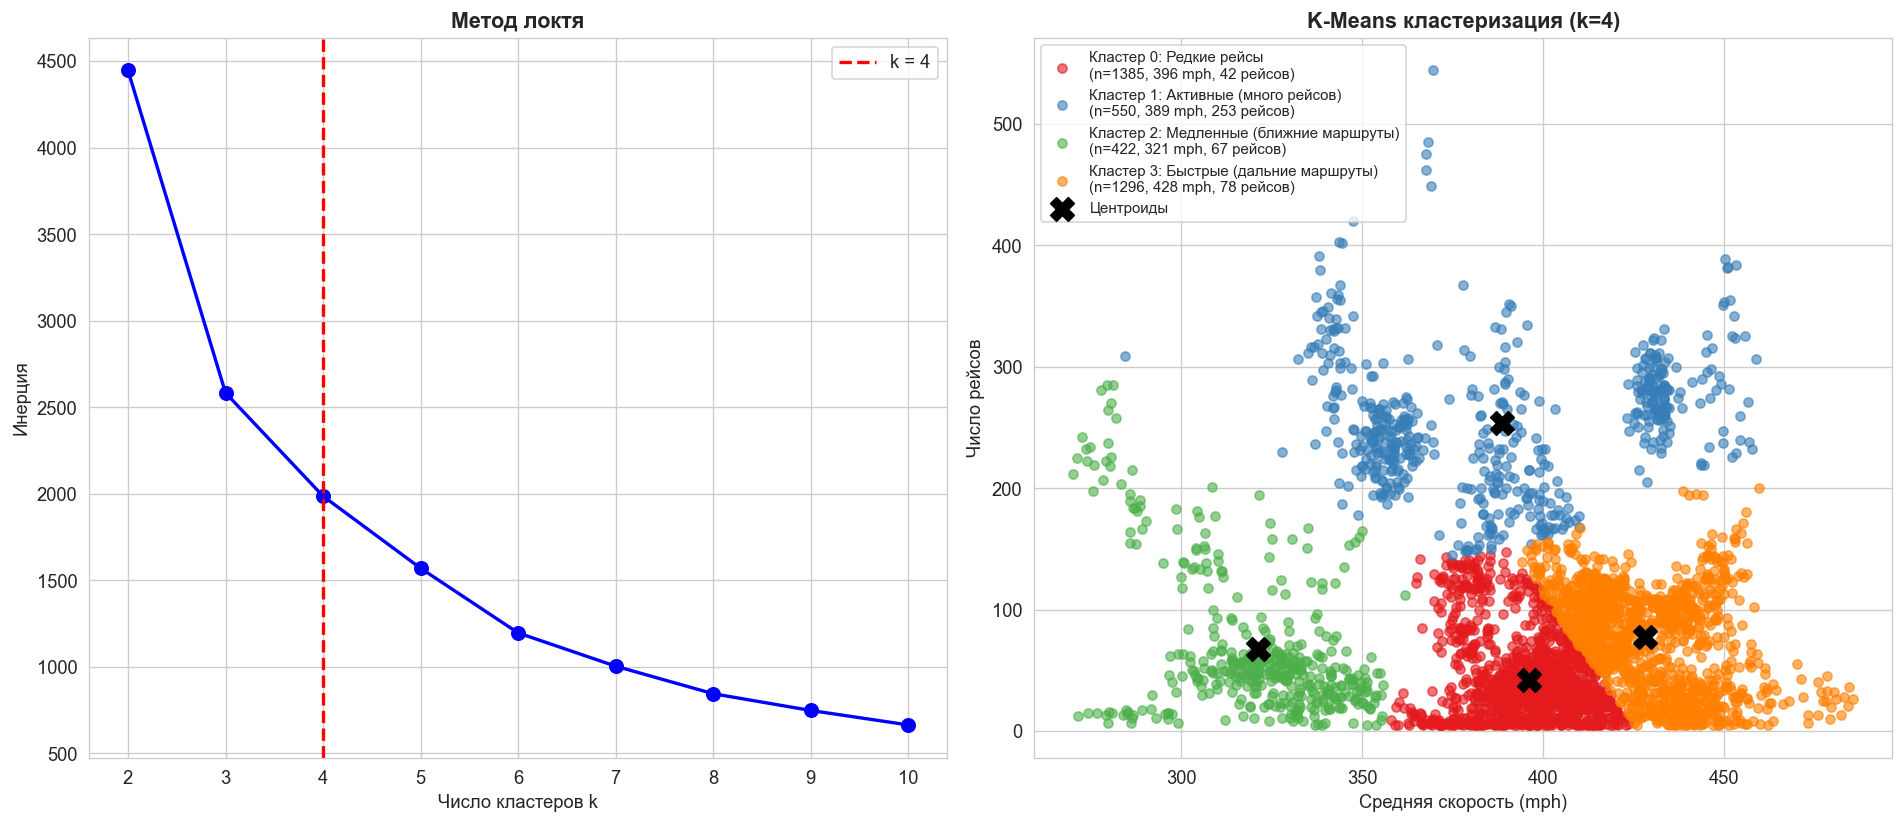

In [6]:
features = plane_stats[['mean_speed', 'n_flights']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(km.fit(X_scaled).inertia_)

K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
plane_stats['cluster'] = kmeans.fit_predict(X_scaled)

cluster_stats = plane_stats.groupby('cluster').agg(
    count=('tailnum', 'count'),
    mean_speed=('mean_speed', 'mean'),
    mean_flights=('n_flights', 'mean'),
    mean_distance=('mean_distance', 'mean')
).round(1)
display(cluster_stats)

names = {}
names[cluster_stats['mean_speed'].idxmax()] = 'Быстрые (дальние маршруты)'
names[cluster_stats['mean_speed'].idxmin()] = 'Медленные (ближние маршруты)'
rest = [c for c in range(K) if c not in names]
if len(rest) >= 2:
    flights_vals = {c: cluster_stats.loc[c, 'mean_flights'] for c in rest}
    names[max(flights_vals, key=flights_vals.get)] = 'Активные (много рейсов)'
    names[min(flights_vals, key=flights_vals.get)] = 'Редкие рейсы'

for c, name in names.items():
    r = cluster_stats.loc[c]
    print(f'Кластер {c} — {name}: {r["count"]:.0f} самолетов, {r["mean_speed"]:.0f} mph, {r["mean_flights"]:.0f} рейсов')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(K, color='red', linestyle='--', linewidth=2, label=f'k = {K}')
axes[0].set_title('Метод локтя', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Число кластеров k')
axes[0].set_ylabel('Инерция')
axes[0].legend()

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']
for cid in range(K):
    mask = plane_stats['cluster'] == cid
    subset = plane_stats[mask]
    r = cluster_stats.loc[cid]
    label = f"Кластер {cid}: {names.get(cid, '')}\n(n={mask.sum()}, {r['mean_speed']:.0f} mph, {r['mean_flights']:.0f} рейсов)"
    axes[1].scatter(subset['mean_speed'], subset['n_flights'], c=colors[cid], alpha=0.6, s=30, label=label)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
axes[1].scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, zorder=5, label='Центроиды')
axes[1].set_title(f'K-Means кластеризация (k={K})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Средняя скорость (mph)')
axes[1].set_ylabel('Число рейсов')
axes[1].legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('charts/5_clusters.png', bbox_inches='tight')
plt.show()

### Вывод
Кластеризация выделила четыре содержательные группы самолетов: быстрые самолеты дальних маршрутов, медленные самолеты ближних маршрутов, самолеты с высокой интенсивностью эксплуатации и самолеты с редкими вылетами. Такой результат показывает, что даже по двум признакам можно получить интерпретируемую сегментацию парка.

## Итоговый вывод

Проведенный анализ показал различия между авиакомпаниями по вероятности задержек, обнаружил статистически значимую разницу в скоростях между `WN` и `UA`, подтвердил сильную связь между скоростью и дальностью маршрутов, а также позволил сегментировать самолеты на четыре интерпретируемые группы. Ноутбук содержит полный ход исследования, таблицы, графики и выводы по каждому пункту задания.